In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

import aymansigmri as asm

In [4]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)
#radial_interp_coils = asm.gridding_operator_H(cartesian_data=kspace_cart_coils, coord=zte_radial_coords)

In [5]:
def nufft_gridding(kspace, coords):
    n_coils = kspace.shape[0]
    n_samples = kspace.shape[-1]
    dcf = np.sqrt(coords[..., 0]**2 + coords[..., 1]**2)
    imagegrid = sp.nufft_adjoint(kspace * dcf, coords, oshape=(n_coils, n_samples, n_samples))
    gridded_data = sp.fft(imagegrid, axes=(-2, -1), norm=None)
    return gridded_data

## Problem - NUFFT Degridding

- Current Loss of Information

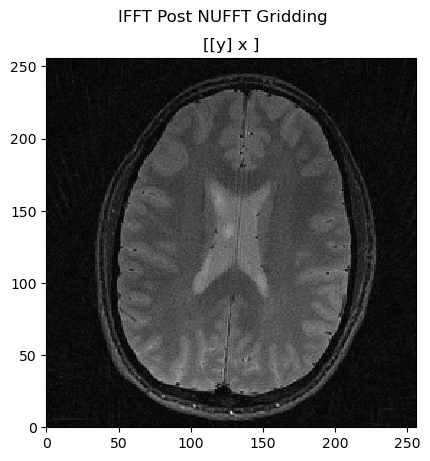

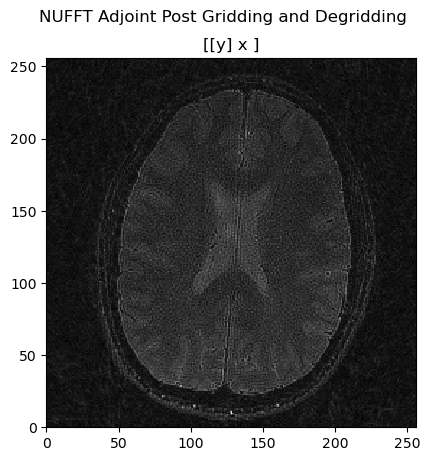

In [6]:
# Plot the image after gridding and then again after degridding
zte_cart_kspace_imgtrip = nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)

#Post grid
im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip)
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5
pl.ImagePlot(im_rss_cart,title='IFFT Post NUFFT Gridding')


#Post degrid
radial_post_imtrip = sp.nufft(im_cart_grid, zte_radial_coords, oversamp=1, width=10)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(radial_post_imtrip * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(zte_img_rss, title='NUFFT Adjoint Post Gridding and Degridding')

## Investigating image difference

In [27]:
### Original Image
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_orig_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
zte_orig_image = np.sum(np.abs(zte_orig_grid)**2, axis=0)**0.5


### Post gridding with nufft
zte_cart_kspace_imgtrip = nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)
im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip,norm=None,oshape=(12,256,256))
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5


### Post image - nufft on the cartesian image grid
radial_post_imtrip = sp.nufft(im_cart_grid, zte_radial_coords)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)

zte_img_grid = sp.nufft_adjoint(radial_post_imtrip * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5


#Div to find scaling problem
div = zte_img_rss / im_rss_cart

In [28]:
print(np.percentile(np.abs(zte_img_rss), 90)) 
print(np.percentile(np.abs(zte_img_rss), 95)) 
print(np.percentile(np.abs(zte_img_rss), 99))   
print(np.abs(zte_img_rss).max())                
print(np.percentile(np.abs(im_rss_cart), 99))
print(np.abs(im_rss_cart).max())

0.1202290514848536
0.13353170347382462
0.16122046373936985
0.4560777442615662
0.0020884859824684223
0.004123434735480603


### Plot with colourbars
- reveals scaling issue in the operations

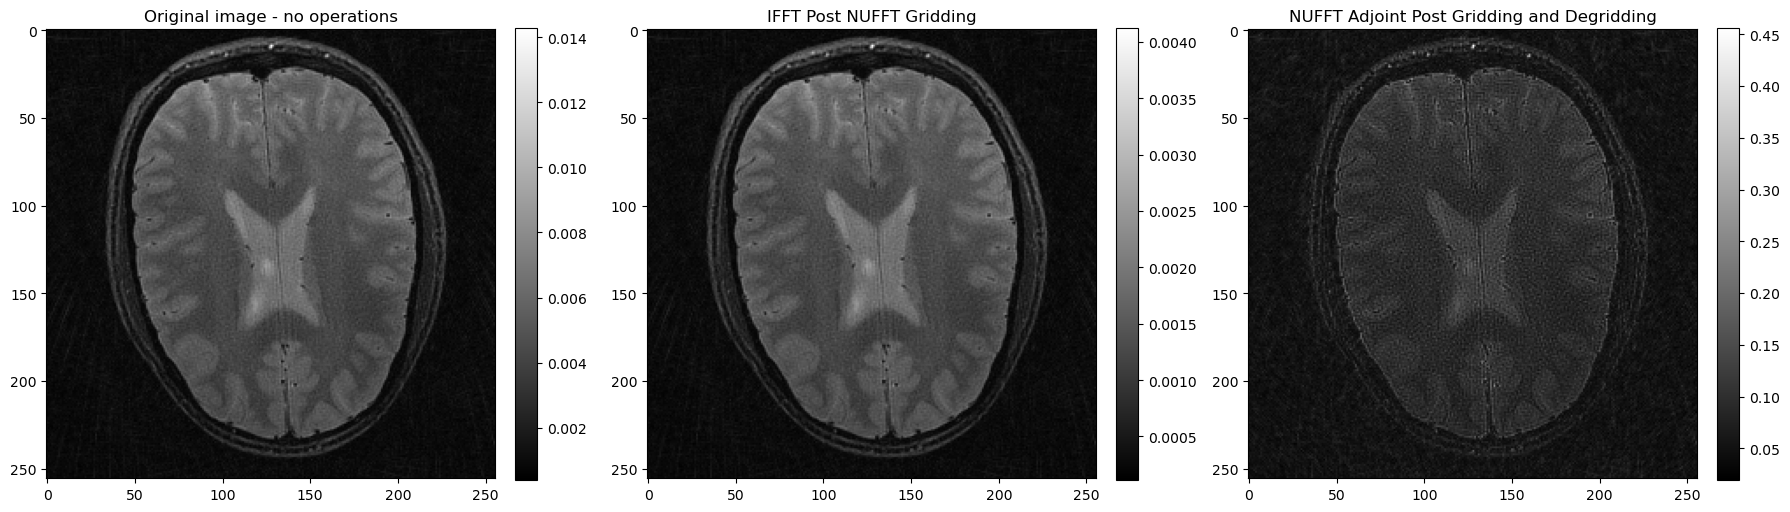

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))

im0 = ax[0].imshow(zte_orig_image, cmap='gray')
ax[0].set_title('Original image - no operations')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(im_rss_cart, cmap='gray')
ax[1].set_title('IFFT Post NUFFT Gridding')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(zte_img_rss, cmap='gray')
ax[2].set_title('NUFFT Adjoint Post Gridding and Degridding')
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Plot kspace vals

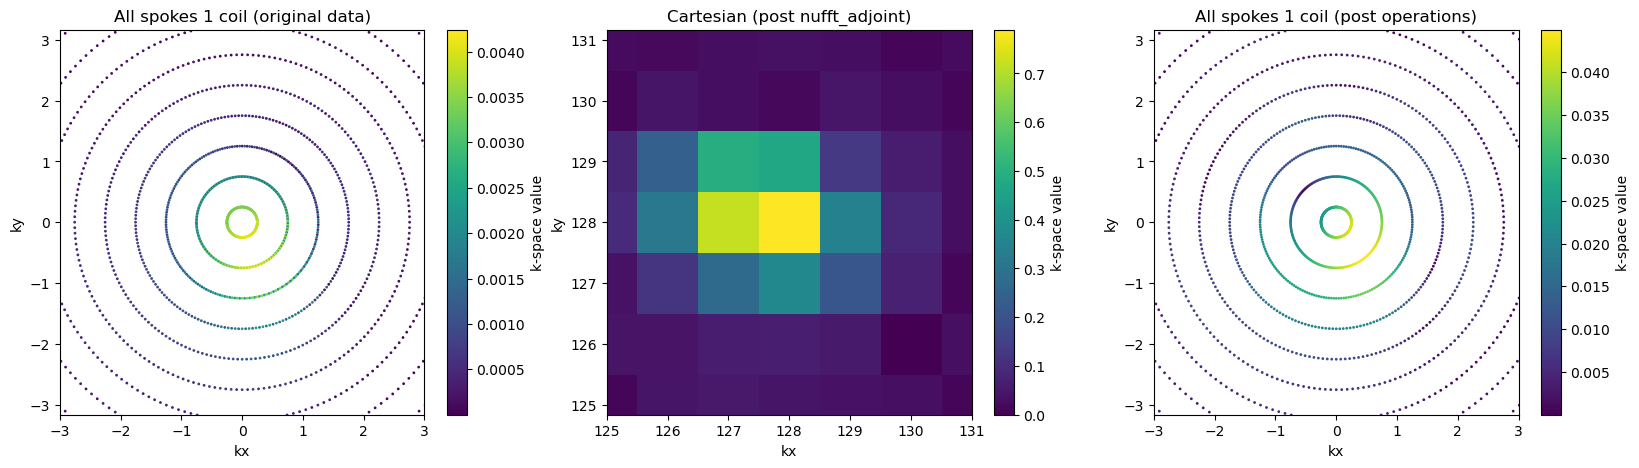

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)

all_kspace_postim = radial_post_imtrip[0].reshape(-1)


im0 = ax[0].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[0].set_title('All spokes 1 coil (original data)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(0 - 3,0 + 3)
ax[0].set_ylim(0 - 3,0 + 3)
fig.colorbar(im0, ax=ax[0], label='k-space value')

im1 = ax[1].imshow(np.abs(kspace_cart_coils[0]))
ax[1].set_title('Cartesian (post nufft_adjoint)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
ax[1].set_xlim(256/2 - 3,256/2 + 3)
ax[1].set_ylim(256/2 - 3,256/2 + 3)
fig.colorbar(im1, ax=ax[1], label='k-space value')

im1 = ax[2].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace_postim), s=1)
ax[2].set_title('All spokes 1 coil (post operations)')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].set_xlim(0 - 3,0 + 3)
ax[2].set_ylim(0 - 3,0 + 3)
fig.colorbar(im1, ax=ax[2], label='k-space value')


plt.show()

In [134]:
test_round_trip = sp.nufft_adjoint(sp.nufft(im_cart_grid, zte_radial_coords), zte_radial_coords)
scale_factor =  np.abs(test_round_trip).max() / np.abs(im_cart_grid).max()
print(f"Scale factor: {scale_factor:.4f}") 

Scale factor: 31.7256
